# Modul 1 - Eksplorasi Paralelisme Dasar

## Program Serial

In [9]:
import random
import time
import math

def calculate_pi_serial(num_samples):
    inside_circle = 0

    for _ in range(num_samples):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)

        if x**2 + y**2 <= 1:
            inside_circle += 1

    pi_estimate = 4 * inside_circle / num_samples
    return pi_estimate

num_samples = 10_000_000

start_time = time.time()

pi_est = calculate_pi_serial(num_samples)

end_time = time.time()

serial_time = end_time - start_time

print(f"Estimasi π: {pi_est}")
print(f"Nilai asli π: {math.pi}")
print(f"Error : {abs(pi_est - math.pi)}")
print(f"Waktu eksekusi : {serial_time:.4f} detik")

Estimasi π: 3.1414516
Nilai asli π: 3.141592653589793
Error : 0.00014105358979321636
Waktu eksekusi : 2.3163 detik


## Program Paralel Multiprocessing

In [5]:
import multiprocessing
import random
import time
import math

def monte_carlo_chunk(chunk_size):
    inside = 0

    for _ in range(chunk_size):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)

        if x**2 + y**2 <= 1:
            inside += 1
            
    return inside

def calculate_pi_parallel(num_samples, num_processes):
    
    chunk_size = num_samples // num_processes
    
    with multiprocessing.Pool(processes=num_processes) as pool:
        results = pool.map(
            monte_carlo_chunk,
            [chunk_size] * num_processes
        )

    total_inside = sum(results)

    pi_estimate = (
        4 * total_inside /
        (chunk_size * num_processes)
    )

    return pi_estimate

num_samples = 10_000_000

results_data = []

for num_procs in [1, 2, 4, 8, 16, 32]:

    start_time = time.time()

    pi_est = calculate_pi_parallel(
        num_samples,
        num_procs
    )

    end_time = time.time()

    parallel_time = end_time - start_time

    speedup = serial_time / parallel_time
    efficiency = speedup / num_procs

    results_data.append([
        num_procs,
        parallel_time,
        speedup,
        efficiency
    ])

    print(f"\nProcess : {num_procs}")
    print(f"π : {pi_est}")
    print(f"Waktu : {parallel_time:.4f}")
    print(f"Speedup : {speedup:.4f}")
    print(f"Efficiency : {efficiency:.4f}")


Process : 1
π : 3.1413132
Waktu : 2.2893
Speedup : 0.9948
Efficiency : 0.9948

Process : 2
π : 3.1410108
Waktu : 1.2750
Speedup : 1.7861
Efficiency : 0.8931

Process : 4
π : 3.1421052
Waktu : 0.7089
Speedup : 3.2126
Efficiency : 0.8032

Process : 8
π : 3.1419868
Waktu : 0.6229
Speedup : 3.6562
Efficiency : 0.4570

Process : 16
π : 3.1418632
Waktu : 0.6244
Speedup : 3.6471
Efficiency : 0.2279

Process : 32
π : 3.1420876
Waktu : 0.7843
Speedup : 2.9035
Efficiency : 0.0907


## Grafik Speedup

<function matplotlib.pyplot.show(close=None, block=None)>

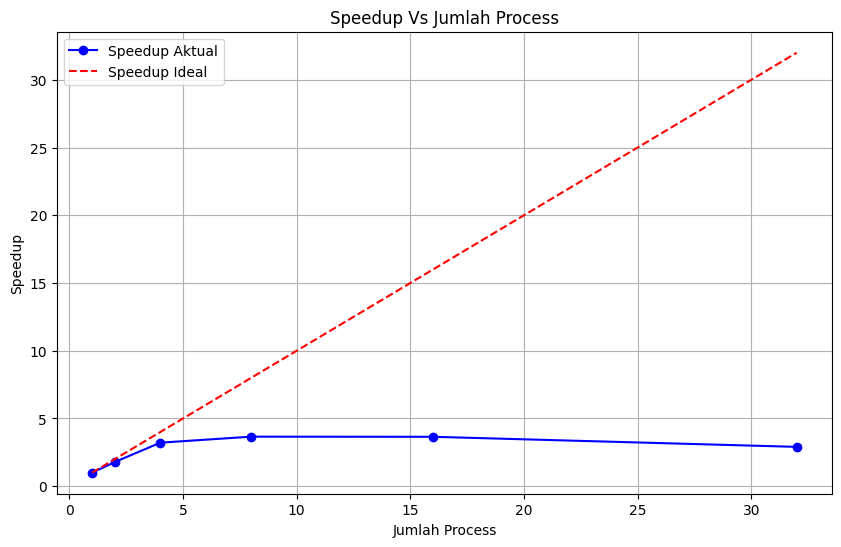

In [8]:
import matplotlib.pyplot as plt

process_counts = [1, 2, 4, 8, 16, 32]

speedups = [
    0.9948,
    1.7861,
    3.2126,
    3.6562,
    3.6471,
    2.9035
]

ideal_speedup = process_counts

plt.figure(figsize=(10,6))

plt.plot(
    process_counts,
    speedups,
    'bo-',
    label ='Speedup Aktual'
)

plt.plot(
    process_counts,
    ideal_speedup,
    'r--',
    label ='Speedup Ideal'
)

plt.xlabel('Jumlah Process')
plt.ylabel('Speedup')
plt.title('Speedup Vs Jumlah Process')

plt.legend()
plt.grid(True)

plt.savefig('speedup_analysis.png')

plt.show